In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

# Long's surface downward SW Rad

As suggested by Bill:

> If you would like to cross compare surface downwelling shortwave radiation, a good obs dataset to use is the qcradlong product (Long is a person's name and not just longwave radiation :slightly_smiling_face: ). You can find this data in the archive folder mounted to the jupyter server.

> QCRAD surface radiation product: /data/project/sgpqcrad1longE13.c2
Example file = sgpqcrad1longE13.c2.20180709.000000.cdf

> Note, I had trouble opening the file directly in xarray. If I first opened it with the netCDF4 library, then xarray worked. Don't know why...

In [2]:
import pandas as pd
SW_PATH = '/data/archive/sgp/sgpqcrad1longE13.c2/'

CASE_DATES = [20180709,
              20190517,
              20190919]

# SW_FILENAME = 'sgpqcrad1longE13.c2.20180709.000000.cdf'
SW_FILENAMES = [f'sgpqcrad1longE13.c2.{date}.000000.cdf' for date in CASE_DATES]

In [3]:
sw_dpscream_list = []
sw_lasso_list = []
for date in CASE_DATES:

    cur_day_fname = f'sgpqcrad1longE13.c2.{date}.000000.cdf'
    next_day_fname = f'sgpqcrad1longE13.c2.{date+1}.000000.cdf' # won;t work for end of month but these dates are convenient!
    sw_case = xr.open_mfdataset([SW_PATH+cur_day_fname, SW_PATH+next_day_fname]).BestEstimate_down_short_hemisp

    # now the case would start from 00:00UTC.

    # for DPSCREAM, data range is hourly from 13UTC to 3UTC the next day; temp res = 1h

    sw_case_dpscream = sw_case.isel(time=slice(13*60, (24+3+1)*60)).resample(time='1h').mean()
    sw_case_dpscream = sw_case_dpscream.assign_coords(time=sw_case_dpscream.time - pd.Timedelta(hours=6))
    sw_dpscream_list.append(sw_case_dpscream)


    # for LASSO, 06:00 - 21:00 local time UTC-6; temp res = 10min
    # so 12UTC to 27UTC (3UTC next day)
    sw_case_lasso = sw_case.isel(time=slice(12*60, (24+3+1)*60)).resample(time='10min').mean()
    sw_case_lasso = sw_case_lasso.assign_coords(time=sw_case_lasso.time - pd.Timedelta(hours=6))
    sw_lasso_list.append(sw_case_lasso)


sw_dpscream = xr.concat(
    sw_dpscream_list,
    dim='case'
)

sw_lasso = xr.concat(
    sw_lasso_list,
    dim='case'
)

    

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


## Usage:

`sw_dpscream` and `sw_lasso` DataArrays, specify case (0-2).

### Demo:

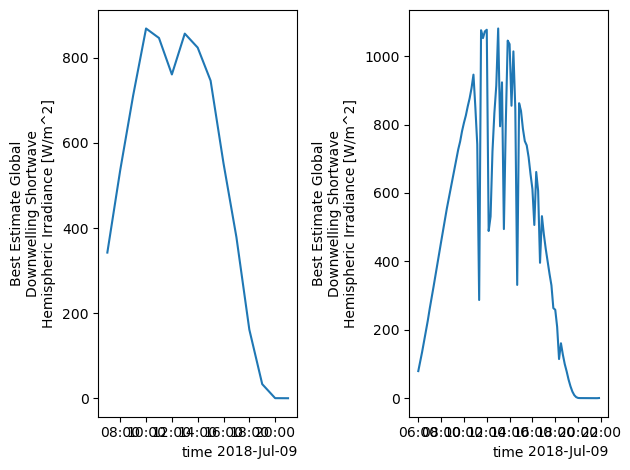

In [4]:
plt.subplot(1,2,1)
sw_dpscream.isel(case=0).plot()
plt.subplot(1,2,2)

sw_lasso.isel(case=0).plot()

plt.tight_layout()

In [5]:
sw_file.BestEstimate_down_short_hemisp.plot()

NameError: name 'sw_file' is not defined

In [33]:
may_2019_data_path = r'/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_2019-05-17.fullfield.AVERAGE.nhours_x1.2019-05-17-43200.nc'

ncfid = xr.open_dataset(may_2019_data_path)

da = ncfid.cldfrac_tot_for_analysis
da_xy = (
    da
    .assign_coords(
        x=("ncol", np.tile(np.arange(10), 10)),
        y=("ncol", np.repeat(np.arange(10), 10)),
    )
    .set_index(ncol=("x", "y"))
    .unstack("ncol")
    .transpose("time", "x", "y", "lev")
)
da_xy

<xarray.DataArray 'cldfrac_tot_for_analysis' (time: 15, x: 10, y: 10, lev: 128)> Size: 768kB
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]], dtype=float32)
Coordinates:
  * x        (x) int64 80B 0 1 2 3 4 5 6 7 8 9
  * y        (y) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time     (time) datetime64[ns] 120B 2019-05-17T13:00:00 ... 2019-05-18T03...
    lat      (x, y) float32 400B 2.5e+03 7.5e+03 1.25e+04 ... 4.25e+04 4.75e+04
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5
    lon      (x, y) float32 400B 2.5e+03 2.25e+04 2.5e+03 ... 2.75e+04 4.75e+04
Attributes:
    units:                    1
    averaging_count_tracker:  avg_count_ncol_lev
    long_name:                MISSING
    standard_name:            cloud_area_fraction_in_atmosphere_layer
    cell_methods:             time: mean

In [1]:
da.isel(time=0).isel(ncol=0)

NameError: name 'da' is not defined

In [2]:
from glob import glob
# files_in = glob("/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc")
# ds_dp_scream = xr.open_mfdataset(files_in, combine='nested', concat_dim = 'date')

ds_dp_scream = xr.open_dataset(may_2019_data_path)
ds_dp_scream = ds_dp_scream.assign_coords(time=ds_dp_scream.time - pd.Timedelta(hours=6))

x = np.unique(ds_dp_scream.lon.values)   # 10 values: 2500, 7500, ..., 47500 m
y = np.unique(ds_dp_scream.lat.values)   # same

cf_colmax = ds_dp_scream['cldfrac_tot_for_analysis'].max(dim='lev')   # (time, ncol)
#######################################################################################
cf_860hpa = ds_dp_scream['cldfrac_tot_for_analysis'].isel(lev=100)   # (time, ncol)
#######################################################################################

cf_scream = xr.DataArray(
  cf_860hpa.values.reshape(ds_dp_scream.sizes['time'], len(y), len(x)),
  dims=['time', 'y', 'x'],
  coords={
      'time': ds_dp_scream.time,
      'y': y,
      'x': x,
  },
  attrs={'units': '1', 'long_name': 'Column-max total cloud fraction'},
)

cf_scream.isel(time = 11).plot()

NameError: name 'xr' is not defined

In [141]:
ds_dp_scream['cldfrac_tot_for_analysis'].isel(lev=100)

<xarray.DataArray 'cldfrac_tot_for_analysis' (time: 15, ncol: 100)> Size: 6kB
[1500 values with dtype=float32]
Coordinates:
    lat      (ncol) float32 400B 2.5e+03 2.5e+03 7.5e+03 ... 4.75e+04 4.75e+04
    lev      float32 4B 860.4
    lon      (ncol) float32 400B 2.5e+03 7.5e+03 2.5e+03 ... 4.25e+04 4.75e+04
  * time     (time) datetime64[ns] 120B 2019-05-17T07:00:00 ... 2019-05-17T21...
Dimensions without coordinates: ncol
Attributes:
    units:                    1
    averaging_count_tracker:  avg_count_ncol_lev
    long_name:                MISSING
    standard_name:            cloud_area_fraction_in_atmosphere_layer
    cell_methods:             time: mean

In [134]:
da_xy

<xarray.DataArray 'cldfrac_tot_for_analysis' (time: 15, x: 10, y: 10, lev: 128)> Size: 768kB
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]], dtype=float32)
Coordinates:
  * x        (x) int64 80B 0 1 2 3 4 5 6 7 8 9
  * y        (y) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time     (time) datetime64[ns] 120B 2019-05-17T13:00:00 ... 2019-05-18T03...
    lat      (x, y) float32 400B 2.5e+03 7.5e+03 1.25e+04 ... 4.25e+04 4.75e+04
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5
    lon      (x, y) float32 400B 2.5e+03 2.25e+04 2.5e+03 ... 2.75e+04 4.75e+04
Attributes:
    units:                    1
    averaging_count_tracker:  avg_count_ncol_lev
    long_name:                MISSING
    standard_name:            cloud_area_fraction_in_atmosphere_layer
    cell_methods:             time: mean

ValueError: ('lev', 'time') must be a permuted list of FrozenMappingWarningOnValuesAccess({'time': 15, 'dim2': 2, 'ncol': 100, 'lev': 128, 'ilev': 129, 'lwband': 16, 'swband': 14}), unless `...` is included

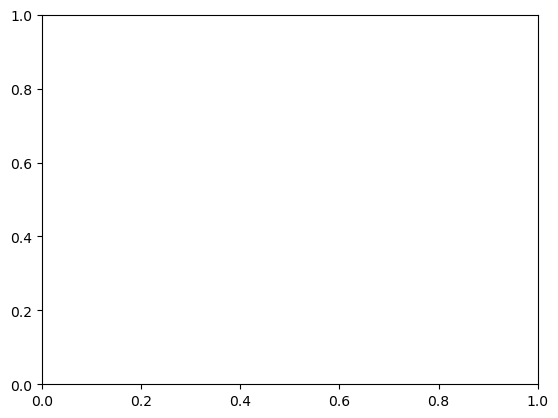

In [101]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    ncfid["time"],
    ncfid.z_mid,  # (time, p)
    ncfid.transpose("lev", "time"),
    shading="auto"
)

ax.set_xlabel("Time")
ax.set_ylabel("Height (z)")
plt.colorbar(pcm, ax=ax, label="Cloud fraction")

In [102]:
ncfid.z_mid

<xarray.DataArray 'z_mid' (time: 15, ncol: 100, lev: 128)> Size: 768kB
array([[[38400.06   , 37053.51   , ...,   365.57925,   334.25763],
        [38400.05   , 37053.508  , ...,   365.572  ,   334.2553 ],
        ...,
        [38400.06   , 37053.51   , ...,   365.58267,   334.25916],
        [38400.055  , 37053.508  , ...,   365.5851 ,   334.25977]],

       [[38405.89   , 37057.64   , ...,   365.7123 ,   334.3034 ],
        [38405.895  , 37057.65   , ...,   365.70798,   334.30212],
        ...,
        [38405.895  , 37057.65   , ...,   365.7216 ,   334.3061 ],
        [38405.895  , 37057.645  , ...,   365.71893,   334.30533]],

       ...,

       [[38707.457  , 37279.68   , ...,   366.09564,   334.41077],
        [38707.664  , 37279.957  , ...,   366.089  ,   334.40842],
        ...,
        [38706.645  , 37279.766  , ...,   366.1222 ,   334.41913],
        [38706.93   , 37279.586  , ...,   366.09357,   334.41006]],

       [[38704.77   , 37280.67   , ...,   366.0483 ,   334.39584],
        [38704.83   , 37280.242  , ...,   366.12302,   334.4202 ],
        ...,
        [38705.664  , 37281.527  , ...,   365.9037 ,   334.3452 ],
        [38705.03   , 37281.168  , ...,   365.8676 ,   334.33054]]],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-09-29T13:00:00 ... 2019-09-30T03...
    lat      (ncol) float32 400B 2.5e+03 2.5e+03 7.5e+03 ... 4.75e+04 4.75e+04
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5
    lon      (ncol) float32 400B 2.5e+03 7.5e+03 2.5e+03 ... 4.25e+04 4.75e+04
Dimensions without coordinates: ncol
Attributes:
    units:                    m
    averaging_count_tracker:  avg_count_ncol_lev
    long_name:                elevation above sealevel at level midpoints
    standard_name:            geopotential_height
    cell_methods:             time: mean

In [103]:
ncfid.cldfrac_tot_for_analysis

<xarray.DataArray 'cldfrac_tot_for_analysis' (time: 15, ncol: 100, lev: 128)> Size: 768kB
array([[[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00]],

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00]],

       ...,

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00]],

       [[0.000000e+00, 0.000000e+00, ..., 1.163311e-13, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00]]],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-09-29T13:00:00 ... 2019-09-30T03...
    lat      (ncol) float32 400B 2.5e+03 2.5e+03 7.5e+03 ... 4.75e+04 4.75e+04
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5
    lon      (ncol) float32 400B 2.5e+03 7.5e+03 2.5e+03 ... 4.25e+04 4.75e+04
Dimensions without coordinates: ncol
Attributes:
    units:                    1
    averaging_count_tracker:  avg_count_ncol_lev
    long_name:                MISSING
    standard_name:            cloud_area_fraction_in_atmosphere_layer
    cell_methods:             time: mean

In [104]:
cf_mean = ncfid.cldfrac_tot_for_analysis.mean("ncol")
z_mean  = ncfid.z_mid.mean("ncol")

In [106]:
cf_mean["time"]

<xarray.DataArray 'time' (time: 15)> Size: 120B
array(['2019-09-29T13:00:00.000000000', '2019-09-29T14:00:00.000000000',
       '2019-09-29T15:00:00.000000000', '2019-09-29T16:00:00.000000000',
       '2019-09-29T17:00:00.000000000', '2019-09-29T18:00:00.000000000',
       '2019-09-29T19:00:00.000000000', '2019-09-29T20:00:00.000000000',
       '2019-09-29T21:00:00.000000000', '2019-09-29T22:00:00.000000000',
       '2019-09-29T23:00:00.000000000', '2019-09-30T00:00:00.000000000',
       '2019-09-30T01:00:00.000000000', '2019-09-30T02:00:00.000000000',
       '2019-09-30T03:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-09-29T13:00:00 ... 2019-09-30T03...

In [107]:
z_mean

<xarray.DataArray 'z_mid' (time: 15, lev: 128)> Size: 8kB
array([[38400.023  , 37053.5    , 35957.664  , ...,   400.50037,
          365.57083,   334.25546],
       [38405.902  , 37057.67   , 35961.25   , ...,   400.71628,
          365.71573,   334.30438],
       [38421.785  , 37068.28   , 35969.86   , ...,   401.0534 ,
          365.90723,   334.362  ],
       ...,
       [38711.344  , 37282.363  , 36143.39   , ...,   401.63928,
          366.2169 ,   334.44772],
       [38707.13   , 37280.12   , 36140.996  , ...,   401.47327,
          366.11737,   334.41656],
       [38705.63   , 37280.67   , 36141.4    , ...,   401.33383,
          366.0335 ,   334.39032]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-09-29T13:00:00 ... 2019-09-30T03...
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5

TypeError: Incompatible X, Y inputs to pcolormesh; see help(pcolormesh)

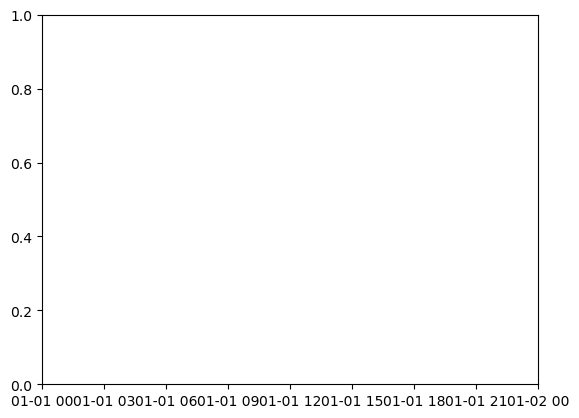

In [105]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(
    cf_mean["time"],
    z_mean,
    cf_mean.transpose("lev", "time"),
    shading="auto"
)

ax.set_xlabel("Time")
ax.set_ylabel("Height (m)")
plt.colorbar(pcm, ax=ax, label="Cloud fraction")

In [108]:
cf_mean.transpose("lev", "time")

<xarray.DataArray 'cldfrac_tot_for_analysis' (lev: 128, time: 15)> Size: 8kB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 5.6106608e-05,
        2.3932223e-05, 9.1491620e-06],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.2116811e-06,
        8.8473344e-09, 3.4654570e-15],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 5.5077033e-20,
        0.0000000e+00, 1.1376872e-02]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 120B 2019-09-29T13:00:00 ... 2019-09-30T03...
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5

## OBS

In [64]:
OBS_2018_PATH = r'/data/project/ARM_Summer_School_2026/data/dpscream/20180709/sgplassohighfreqobsC1.c1/sgpcldfracset01mC1.c1/data/'

OBS_2018_FILENAME='sgpcldfracset01mC1.c1.20180709.000030.nc'

In [65]:
# files = glob("/data/project/ARM_Summer_School_2026/data/dpscream/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 

TypeError: 'module' object is not callable

In [50]:
import pandas as pd
import xarray as xr

WRF_2018 = xr.open_mfdataset(f"{WRF_2018_PATH}*.nc")
WRF_2018

<xarray.Dataset> Size: 41MB
Dimensions:                             (time: 2880, bound: 2, height: 596)
Coordinates:
  * time                                (time) datetime64[ns] 23kB 2018-07-09...
  * height                              (height) float32 2kB 0.16 0.19 ... 18.01
Dimensions without coordinates: bound
Data variables: (12/20)
    base_time                           (time) datetime64[ns] 23kB 2018-07-09...
    time_offset                         (time) datetime64[ns] 23kB dask.array<chunksize=(1440,), meta=np.ndarray>
    time_bounds                         (time, bound) datetime64[ns] 46kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    cloud_fraction_kazrarscl            (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    cloud_fraction_kazrarscl_fgp        (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    cloud_fraction_kazrarscl_std        (time, height) float32 7MB dask.array<chunksize=(1440, 596), meta=np.ndarray>
    ...                                  ...
    qc_region_zenith_count              (time) int32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    solar_altitude                      (time) float32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_solar_altitude                   (time) int32 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                                 (time) float32 12kB 36.6 36.6 ... 36.6
    lon                                 (time) float32 12kB -97.49 ... -97.49
    alt                                 (time) float32 12kB 318.0 ... 318.0
Attributes: (12/14)
    command_line:          idl -R -n cldfracset -s sgp -f C1 -b 20180709 -R
    Conventions:           ARM-1.2
    process_version:       vap-cldfracset-1.2-0.el6
    dod_version:           cldfracset01m-c1-1.0
    input_datastreams:     sgparsclkazr1kolliasC1.c0 : 1.2 : 20180708.000000-...
    site_id:               sgp
    ...                    ...
    data_level:            c1
    location_description:  Southern Great Plains (SGP), Lamont, Oklahoma
    datastream:            sgpcldfracset01mC1.c1
    averaging_interval:    1 min
    doi:                   10.5439/1523482
    history:               created by user malynn on machine chalk at 2020-02...

In [59]:
WRF_2018.time

<xarray.DataArray 'time' (time: 2880)> Size: 23kB
array(['2018-07-09T00:00:30.000000000', '2018-07-09T00:01:30.000000000',
       '2018-07-09T00:02:30.000000000', ..., '2018-07-10T23:57:30.000000000',
       '2018-07-10T23:58:30.000000000', '2018-07-10T23:59:30.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 23kB 2018-07-09T00:00:30 ... 2018-07-10T23...
Attributes:
    long_name:      Time offset from midnight
    standard_name:  time
    bounds:         time_bounds

In [55]:
WRF_VARNAME = 'cloud_fraction_kazrarscl'

/opt/conda/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


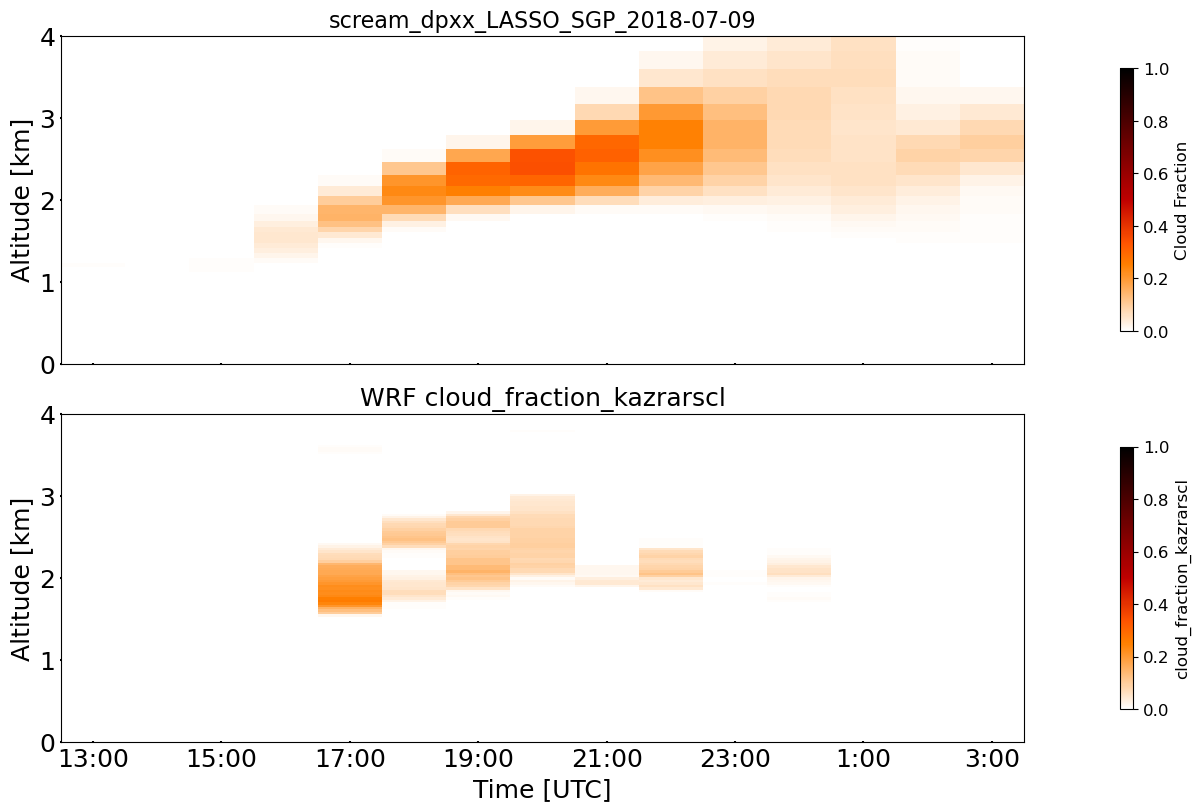

In [63]:
VMIN = 0
VMAX = 1
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    constrained_layout=True,
    figsize=(12, 8),
    sharex=True
)

# =========================
# Top panel (existing plot)
# =========================

ax1.set_ylabel('Altitude [km]', fontsize=18)
ax1.set_title(acase, fontsize=16, loc='center')

ax1.tick_params(
    axis='both',
    which='minor',
    labelsize=18,
    length=0,
    direction='inout',
    width=1.5,
    color='k'
)

ax1.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    length=1,
    direction='inout',
    width=1.5,
    color='k'
)

ax1.set_ylim([0, 4])
ax1.set_yscale('linear')

pm1 = ax1.pcolormesh(
    time,
    zmid,
    cf.transpose(),
    shading='auto',
    vmin = VMIN,
    vmax = VMAX,
    cmap=cmap1
)

cb1 = plt.colorbar(
    pm1,
    ax=ax1,
    shrink=0.8,
    location='right',
    pad=0.1,
)

cb1.ax.tick_params(labelsize=12)
cb1.set_label(label='Cloud Fraction', fontsize=12)

# =========================
# Bottom panel (your DataArray)
# =========================

da = WRF_2018[WRF_VARNAME].sel(time=slice("2018-07-09T13","2018-07-10T03")).resample(time='1H').mean()

ax2.set_ylabel('Altitude [km]', fontsize=18)
ax2.set_xlabel('Time [UTC]', fontsize=18)

ax2.tick_params(
    axis='both',
    which='minor',
    labelsize=18,
    length=0,
    direction='inout',
    width=1.5,
    color='k'
)

ax2.tick_params(
    axis='both',
    which='major',
    labelsize=18,
    length=1,
    direction='inout',
    width=1.5,
    color='k'
)

ax2.set_ylim([0, 4])
ax2.set_yscale('linear')
ax2.set_title(f"WRF {WRF_VARNAME}", fontsize=18)


pm2 = ax2.pcolormesh(
    da['time'],
    da['height'],  
    da.transpose(),
    shading='auto',
    cmap=cmap1,
    vmin = VMIN,
    vmax = VMAX,
)

cb2 = plt.colorbar(
    pm2,
    ax=ax2,
    shrink=0.8,
    location='right',
    pad=0.1,
)

cb2.ax.tick_params(labelsize=12)
cb2.set_label(label=f"{WRF_VARNAME}", fontsize=12)

# =========================
# Shared x ticks
# =========================

ax2.set_xticks(
    time.values[::2],
    labels=[
        str(ii.dt.hour.values) + ':' +
        str(ii.dt.minute.values).zfill(2)
        for ii in time[::2]
    ]
)

plt.show()
plt.close()